In [1]:
!pip install tensorflow==2.16.2 matplotlib==3.9.1 "numpy<2.0"
!pip install jax==0.4.29 jaxlib==0.4.29 ml_dtypes --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.8/590.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 64.5 

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 MB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 95.4 MB/s eta 0:00:00
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.16.2 requires ml-dtypes~=0.3.1, but you have ml-dtypes 0.5.4 which is incompatible.
tensorflow-text 2.20.1 requires tensorfl

In [1]:
import numpy as np
from tensorflow.keras.datasets import mnist

# Load the dataset
(X_train, _), (X_test, _) = mnist.load_data()

# Normalize the pixel value
X_train = X_train.astype('float32')/255
X_test = X_test.astype('float32')/255

# Flatten the image
X_train = X_train.reshape((len(X_train), np.prod(X_train.shape[1:])))
X_test = X_test.reshape((len(X_test), np.prod(X_test.shape[1:])))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Building the Autoencoder Model

In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Encoder
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu')(input_layer)

# Bottleneck
bottleneck = Dense(32, activation='relu')(encoded)

# Decoder
decoded = Dense(64, activation='relu')(bottleneck)
output_layer = Dense(784, activation='sigmoid')(decoded)

# Autoencoder model
autoencoder = Model(input_layer, output_layer)

# Compile the model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Summary of the model
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 105,392 (411.69 KB)

 Trainable params: 105,392 (411.69 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
autoencoder.fit(
    X_train, X_train, epochs=25, batch_size=256, shuffle=True ,
    validation_data=(X_test, X_test)
)

Epoch 1/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2605 - val_loss: 0.1770
Epoch 2/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1597 - val_loss: 0.1442
Epoch 3/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - loss: 0.1364 - val_loss: 0.1275
Epoch 4/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1250 - val_loss: 0.1198
Epoch 5/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1188 - val_loss: 0.1145
Epoch 6/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1138 - val_loss: 0.1102
Epoch 7/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1101 - val_loss: 0.1067
Epoch 8/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1070 - val_loss: 0.1043
Epoch 9/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1050 - val_loss: 0.1030
Epoch 10/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1037 - val_loss: 0.1018
Epoch 11/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1026 - val_loss: 0.1007
Epoch 12/25
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### Evaluating the autoencoder

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


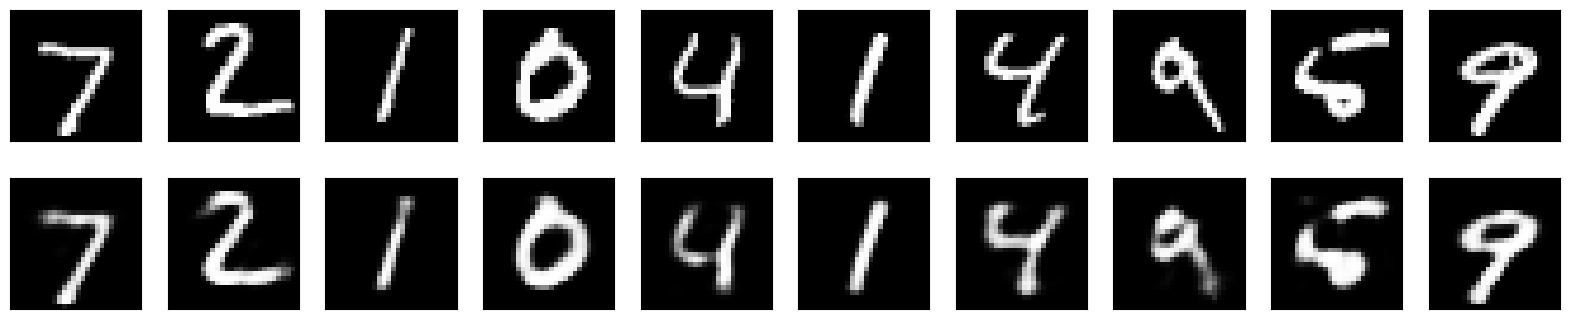

In [4]:
import matplotlib.pyplot as plt

# Predict the test data
reconstructed = autoencoder.predict(X_test)

# Visualize the results
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  # Display original
  ax = plt.subplot(2, n, i+1)
  plt.imshow(X_test[i].reshape(28,28))
  plt.gray()

  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  # Display reconstruction
  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(reconstructed[i].reshape(28,28))
  plt.gray()

  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

plt.show()

In [5]:
# Freeze all layers of the autoencoder
for layer in autoencoder.layers:
    layer.trainable = False

In [6]:
# Check trainable status of each layer
for i, layer in enumerate(autoencoder.layers):
    print(f"Layer {i}: {layer.name}, Trainable = {layer.trainable}")

Layer 0: input_layer, Trainable = False
Layer 1: dense, Trainable = False
Layer 2: dense_1, Trainable = False
Layer 3: dense_2, Trainable = False
Layer 4: dense_3, Trainable = False


In [7]:
# Unfreeze the top layers of the encoder
for layer in autoencoder.layers[-4:]:
    layer.trainable = True

# Compile the model again
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model again
autoencoder.fit(X_train, X_train,
                epochs=10,
                batch_size=256,
                shuffle=True,
                validation_data=(X_test, X_test))

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0941 - val_loss: 0.0927
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0937 - val_loss: 0.0925
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0935 - val_loss: 0.0924
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.0933 - val_loss: 0.0921
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0931 - val_loss: 0.0920
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0929 - val_loss: 0.0920
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0928 - val_loss: 0.0916
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0927 - val_loss: 0.0917
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0925 - val_loss: 0.0915
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0924 - val_loss: 0.0913


Epoch 1/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.1710 - val_loss: 0.1439
Epoch 2/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.1393 - val_loss: 0.1342
Epoch 3/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1327 - val_loss: 0.1298
Epoch 4/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1294 - val_loss: 0.1276
Epoch 5/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.1276 - val_loss: 0.1264
Epoch 6/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.1263 - val_loss: 0.1252
Epoch 7/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.1255 - val_loss: 0.1245
Epoch 8/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.1249 - val_loss: 0.1244
Epoch 9/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.1244 - val_loss: 0.1237
Epoch 10/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1241 - val_loss: 0.1234
Epoch 11/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.1238 - val_loss: 0.1234
Epoch 12/20
118/118 ━━━━━━━━━━━━━━━━━━━━ 

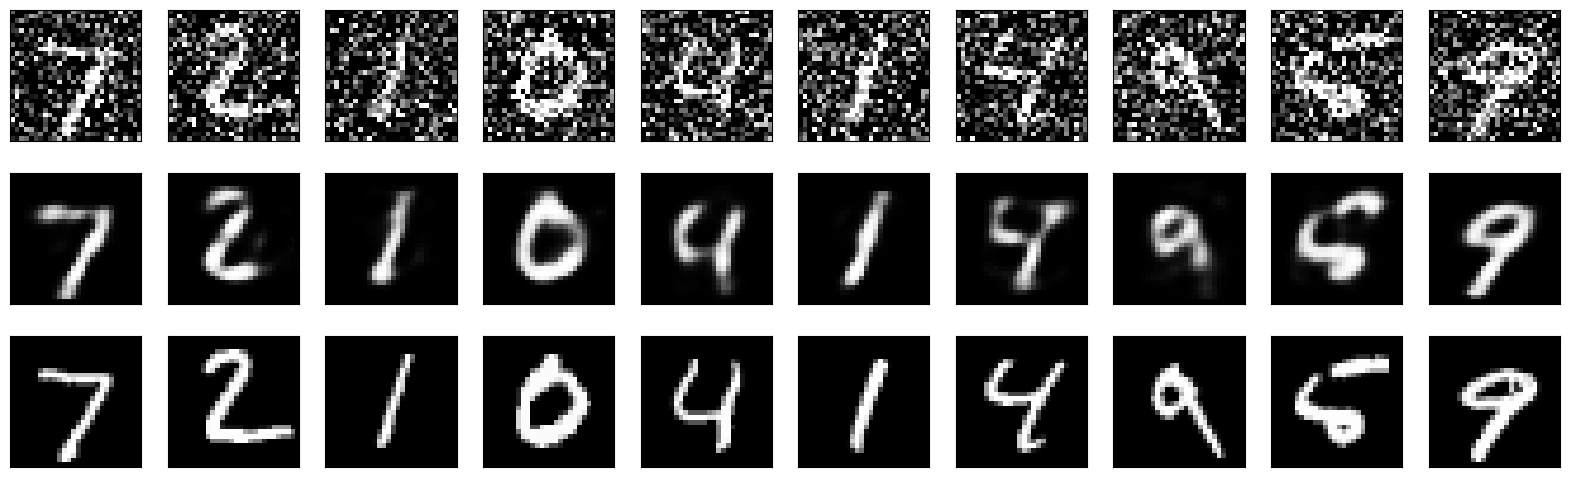

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Add noise to the data
noise_factor = 0.5
X_train_noisy = X_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_train.shape)
X_test_noisy = X_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=X_test.shape)
X_train_noisy = np.clip(X_train_noisy, 0., 1.)
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# Train the autoencoder with noisy data
autoencoder.fit(
    X_train_noisy, X_train,
    epochs=20,
    batch_size=512,
    shuffle=True,
    validation_data=(X_test_noisy, X_test)
)

# Denoise the test images
reconstructed_noisy = autoencoder.predict(X_test_noisy)

# Visualize the results
n = 10  # Number of digits to display
plt.figure(figsize=(20, 6))
for i in range(n):
    # Display noisy images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(X_test_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display denoised images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(reconstructed_noisy[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display original images
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(X_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

plt.show()



### Exploring Different Bottleneck Sizes

#### Objective:

To understand the impact of different bottleneck sizes on the performance of the autoencoder.

#### Instructions:

**1. Define new models with different bottleneck sizes:**
- Create three new autoencoder models, each with a different bottleneck size (e.g., 16, 32, and 64 neurons).
- Use the same encoder and decoder architecture as in the main lab but change the number of neurons in the bottleneck layer.

**2. Train the models:**
- Train each model on the MNIST dataset for 50 epochs with a batch size of 256.
- Use the same preprocessing steps as in the main lab.

**3. Evaluate and Compare the Models:**
- Evaluate the performance of each model on the test data.
- Compare the reconstruction loss of the models to understand how the bottleneck size affects the autoencoder's ability to reconstruct the input data.

In [9]:
# Define and train three different autoencoders with varying bottleneck sizes
bottleneck_sizes = [16, 32, 64]
autoencoders = []

for size in bottleneck_sizes:
    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(64, activation='relu')(input_layer)
    bottleneck = Dense(size, activation='relu')(encoded)

    # Decoder
    decoded = Dense(64, activation='relu')(bottleneck)
    output_layer = Dense(784, activation='sigmoid')(decoded)

    # Autoencoder model
    autoencoder = Model(input_layer, output_layer)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
    autoencoder.fit(
        X_train,
        X_train,
        epochs=20,
        batch_size=256,
        shuffle=True,
        validation_data=(X_test, X_test)
    )
    autoencoders.append(autoencoder)

# Evaluate and compare the models
for i, size in enumerate(bottleneck_sizes):
    loss = autoencoders[i].evaluate(X_test, X_test)
    print(f'Bottleneck size {size} - Test loss: {loss}')

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.2692 - val_loss: 0.1827
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1681 - val_loss: 0.1535
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 0.1464 - val_loss: 0.1370
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1338 - val_loss: 0.1287
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1280 - val_loss: 0.1247
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1248 - val_loss: 0.1225
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1230 - val_loss: 0.1209
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1216 - val_loss: 0.1195
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.1204 - val_loss: 0.1183
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.1193 - val_loss: 0.1174
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1185 - val_loss: 0.1165
Epoch 12/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### Adding Regularization to the Autoencoder

#### Objective:

To explore the effect of regularization on the performance of the autoencoder.

#### Instructions:

**1. Modify the model:**
- Add L2 regularization to the Dense layers in both the encoder and decoder parts of the autoencoder.

**2. Train the model:**
- Train the modified autoencoder on the MNIST dataset for 50 epochs with a batch size of 256.

**3. Evaluate and compare:**
- Evaluate the performance of the regularized autoencoder and compare it with the non-regularized version.

In [10]:
from tensorflow.keras.regularizers import l2

# Encoder with L2 regularization
input_layer = Input(shape=(784,))
encoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(input_layer)
bottleneck = Dense(32, activation='relu', kernel_regularizer=l2(0.01))(encoded)

# Decoder with L2 regularization
decoded = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(bottleneck)
output_layer = Dense(784, activation='sigmoid', kernel_regularizer=l2(0.01))(decoded)

# Autoencoder model with L2 regularization
autoencoder_regularized = Model(input_layer, output_layer)
autoencoder_regularized.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
autoencoder_regularized.fit(X_train, X_train, epochs=50, batch_size=256, shuffle=True, validation_data=(X_test, X_test))

# Evaluate the model
loss = autoencoder_regularized.evaluate(X_test, X_test)
print(f'Regularized Autoencoder - Test loss: {loss}')


Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.9954 - val_loss: 0.4416
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.4122 - val_loss: 0.3960
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.3890 - val_loss: 0.3807
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.3738 - val_loss: 0.3659
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3597 - val_loss: 0.3528
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3481 - val_loss: 0.3428
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3389 - val_loss: 0.3349
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.3313 - val_loss: 0.3277
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3247 - val_loss: 0.3214
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.3187 - val_loss: 0.3159
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.3133 - val_loss: 0.3104
Epoch 12/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 

### Visualizing Intermediate Representations

#### Objective:

To visualize and understand the intermediate representations (encoded features) learned by the autoencoder.

#### Instructions:

**1. Extract Encoder Part:**
- Extract the encoder part of the trained autoencoder to create a separate model that outputs the encoded features.

**2. Visualize Encoded Features:**
- Use the encoder model to transform the test data into the encoded space.
- Plot the encoded features using a scatter plot for the first two dimensions of the encoded space.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


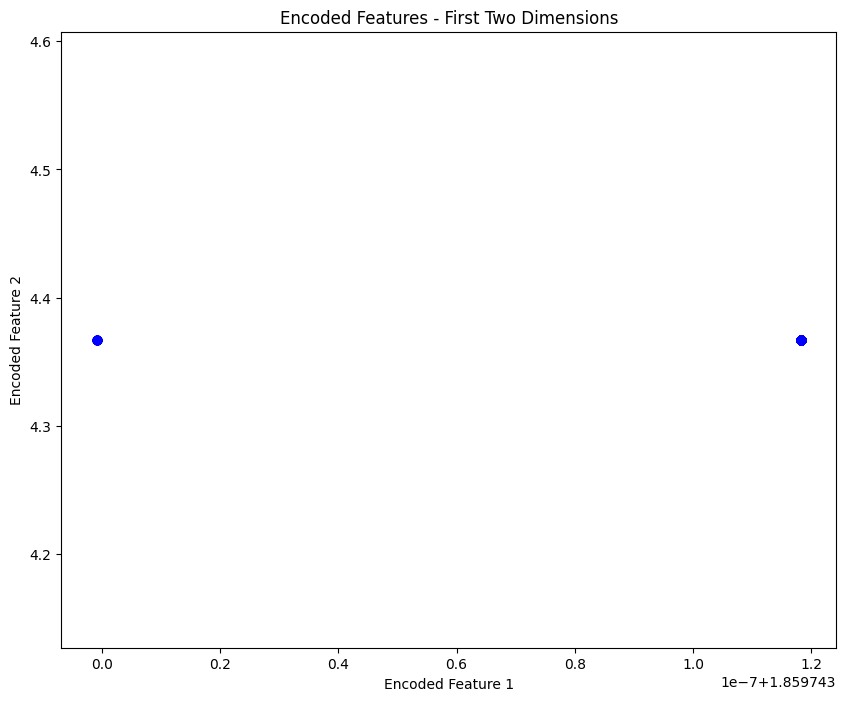

In [12]:
import matplotlib.pyplot as plt

# Extract the encoder part of the autoencoder
encoder_model = Model(input_layer, bottleneck)

# Encode the test data
encoded_imgs = encoder_model.predict(X_test)

# Visualize the first two dimensions of the encoded features
plt.figure(figsize=(10, 8))
plt.scatter(encoded_imgs[:, 0], encoded_imgs[:, 1], c='blue', alpha=0.5)
plt.title('Encoded Features - First Two Dimensions')
plt.xlabel('Encoded Feature 1')
plt.ylabel('Encoded Feature 2')
plt.show()